In [32]:
from settings import INSTANCE_FOLDER
from generation.instances import read_instance
from generation.data import get_best_moves

filepath = INSTANCE_FOLDER / "benchmarks/data5-5-13.dat"
H = 7
max_steps = 100

layout = read_instance(filepath, H)
_, cost = get_best_moves(layout, H, max_steps)

print(cost)

34


In [ ]:
from solvers.FRG import FRGSolver
from solvers.utils import summary

folder = "benchmarks"
max_steps = 50
H = 7

solver = FRGSolver()
solved, steps = solver.solve(filepath, H, max_steps)
#summary(solved, steps)

print(steps)

37


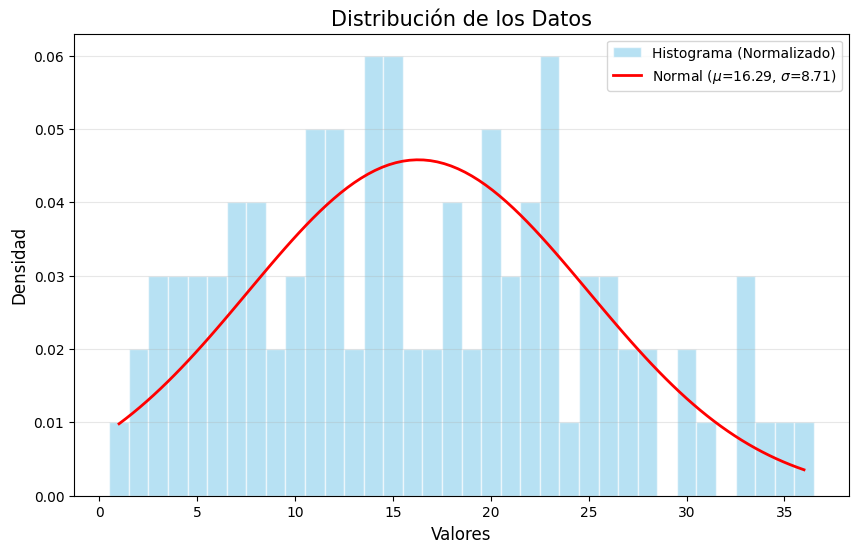

100


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from preprocessing.dataset import load_data

def graficar_distribucion(data, titulo="Distribución de los Datos", color="skyblue"):
    plt.figure(figsize=(10, 6))
    
    # 1. Definir bins que rodeen a cada número entero
    # Esto elimina los huecos artificiales
    bins = np.arange(int(min(data)), int(max(data)) + 2) - 0.5
    
    # 2. Crear el histograma con los bins correctos
    count, bins_hist, ignored = plt.hist(data, bins=bins, density=True, 
                                        alpha=0.6, color=color, edgecolor='white', 
                                        label='Histograma (Normalizado)')
    
    # 3. Para la línea roja, usamos un rango continuo (smooth) en lugar de los bins
    # Esto hace que la curva se vea perfecta y no "poligonal"
    mu, sigma = np.mean(data), np.std(data)
    x = np.linspace(min(data), max(data), 100)
    y = ((1 / (np.sqrt(2 * np.pi) * sigma)) *
         np.exp(-0.5 * (1 / sigma * (x - mu))**2))
    
    plt.plot(x, y, color='red', linewidth=2, label=rf'Normal ($\mu$={mu:.2f}, $\sigma$={sigma:.2f})')
    
    # Estética
    plt.title(titulo, fontsize=15)
    plt.xlabel('Valores', fontsize=12)
    plt.ylabel('Densidad', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

data = load_data("ejemplo_uc.data")
graficar_distribucion(data['C'])

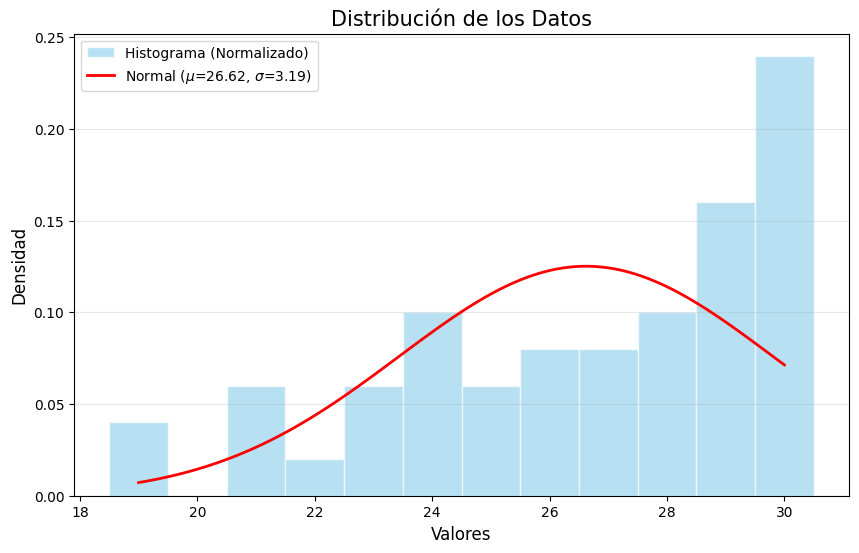

In [5]:
data = load_data("dataset_ejemplo_fr.data")
graficar_distribucion(data['C'])

In [17]:

data = load_data("actions5F_E9-9-RFull.data")
print(np.mean(data['C']))

116.0925


In [12]:
from collections import Counter
from generation.instances import UniformCostGenerator
import numpy as np

a = list(Counter(data['C']).values())
max_steps, _ = UniformCostGenerator(S=5, seed=42).dist(9, 1e10)
max_steps = int(np.floor(max_steps))
a = a[:max_steps]

def min_max_scale(vector):
    v = np.array(vector)
    return (v - v.min()) / (v.max() - v.min())

print(np.mean(a))
print(np.std(a))

1000.0
1884.4376349457682


In [30]:
from preprocessing.dataset import load_data
import numpy as np

S = [i for i in range(3, 10)]
R = [20, 50, 100, 200, 500]

files = []
for s in S:
    for r in R:
        files.append(f"actions5F_E{s}-{s}-R{r}.data")
    files.append(f"actions5F_E{s}-{s}-RFull.data")

mean = []
std = []
s = []
r = []

for sx in S:
    mean.append(1)
    std.append(0)
    s.append(sx)
    r.append(1)

for file in files:
    data = load_data(file)
    mean.append(np.mean(data['C']))
    std.append(np.std(data['C']))

    s.append(int(data['input/S'][0]))
    
    rf = file[16:-5]
    if rf == "Full":
        rf = "1e10"
    r.append(float(rf))

mean = np.array(mean)
std = np.array(std)
print(s)
print(r)

[3, 4, 5, 6, 7, 8, 9, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9]
[1, 1, 1, 1, 1, 1, 1, 20.0, 50.0, 100.0, 200.0, 500.0, 10000000000.0, 20.0, 50.0, 100.0, 200.0, 500.0, 10000000000.0, 20.0, 50.0, 100.0, 200.0, 500.0, 10000000000.0, 20.0, 50.0, 100.0, 200.0, 500.0, 10000000000.0, 20.0, 50.0, 100.0, 200.0, 500.0, 10000000000.0, 20.0, 50.0, 100.0, 200.0, 500.0, 10000000000.0, 20.0, 50.0, 100.0, 200.0, 500.0, 10000000000.0]


In [31]:
import numpy as np
from scipy.optimize import curve_fit

# Convertimos las listas a arreglos de numpy con tipo float
X_a = np.array(s, dtype=float)
X_b = np.array(r, dtype=float)
Y_val = np.array(mean, dtype=float)

# 1. Empaquetar los datos correctamente
# Esto crea una matriz de (2, N) donde la fila 0 es S y la fila 1 es R
X_data = np.vstack((X_a, X_b)) 

def modelo_mu_anclado(variables, k1, k2, p, m, n):
    # Desempaquetar las variables desde la entrada única
    # 'a' corresponde a S, 'b' corresponde a R
    a, b = variables 
    
    # Aseguramos que b-1 no sea negativo para evitar NaNs en la potencia
    b_term = np.maximum(b - 1, 0)
    
    # L_a es el límite asintótico (mu_inf)
    L_a = k1 * (a ** k2)
    # C_a es la constante de saturación
    C_a = np.exp(m * a + n)
    
    crecimiento_maximo = L_a - 1
    # Evitamos división por cero añadiendo un epsilon pequeño en el denominador
    factor_saturacion = (b_term**p) / (C_a + b_term**p + 1e-12)
    
    return 1 + (crecimiento_maximo * factor_saturacion)

# 2. Ajuste de parámetros
# p0 es una estimación inicial para ayudar al algoritmo
try:
    popt, _ = curve_fit(modelo_mu_anclado, X_data, Y_val, p0=[0.9, 2.1, 0.8, 0.4, 1.5])
except RuntimeError as e:
    print(f"Error en el ajuste: {e}")
    popt = [0.9, 2.1, 0.8, 0.4, 1.5] # Valores por defecto en caso de fallo

def predecir_mu(s_val, r_val):
    # Manejo de infinito para validación
    r_input = 1e10 if r_val == float('inf') else float(r_val)
    # modelo_mu_anclado espera un iterable para 'variables'
    y = modelo_mu_anclado((s_val, r_input), *popt)
    return round(y, 4)

# --- RESULTADOS ---
L_str = f"({popt[0]:.4f} * S^{popt[1]:.4f})"
C_str = f"exp({popt[3]:.4f} * S + {popt[4]:.4f})"
print(f"Ecuación optimizada para mu (Anclada en 1):")
print(f"mu = 1 + ({L_str} - 1) * ((R-1)^{popt[2]:.4f} / ({C_str} + (R-1)^{popt[2]:.4f}))")

print("\nValidación Mu:")
for s_test, r_test, real in zip(X_a, X_b, Y_val):
    pred = predecir_mu(s_test, r_test)
    r_label = "inf" if r_test > 1e9 else int(r_test)
    print(f"S={s_test:.1f}, R={r_label:>4} | Real: {real:7.4f} | Pred: {pred:7.4f} | Error: {abs(real-pred):.4f}")

Ecuación optimizada para mu (Anclada en 1):
mu = 1 + ((0.9791 * S^2.1686) - 1) * ((R-1)^0.8746 / (exp(0.4340 * S + 1.5300) + (R-1)^0.8746))

Validación Mu:
S=3.0, R=   1 | Real:  1.0000 | Pred:  1.0000 | Error: 0.0000
S=4.0, R=   1 | Real:  1.0000 | Pred:  1.0000 | Error: 0.0000
S=5.0, R=   1 | Real:  1.0000 | Pred:  1.0000 | Error: 0.0000
S=6.0, R=   1 | Real:  1.0000 | Pred:  1.0000 | Error: 0.0000
S=7.0, R=   1 | Real:  1.0000 | Pred:  1.0000 | Error: 0.0000
S=8.0, R=   1 | Real:  1.0000 | Pred:  1.0000 | Error: 0.0000
S=9.0, R=   1 | Real:  1.0000 | Pred:  1.0000 | Error: 0.0000
S=3.0, R=  20 | Real:  7.3645 | Pred:  5.1894 | Error: 2.1751
S=3.0, R=  50 | Real:  9.6031 | Pred:  7.1396 | Error: 2.4635
S=3.0, R= 100 | Real: 10.2189 | Pred:  8.3595 | Error: 1.8594
S=3.0, R= 200 | Real: 10.3534 | Pred:  9.2399 | Error: 1.1135
S=3.0, R= 500 | Real: 10.3503 | Pred:  9.9421 | Error: 0.4082
S=3.0, R= inf | Real:  8.8320 | Pred: 10.6051 | Error: 1.7731
S=4.0, R=  20 | Real:  7.6090 | Pred: 

In [36]:
import numpy as np
from scipy.optimize import curve_fit

# Datos (tus listas s, r, std)
x1 = np.array(s)
x2 = np.array(r)
y2 = np.array(std)

def modelo_sigma_anclado(variables, a0, a1, b0, b1, c0, c1, p):
    v1, v2 = variables
    # Forzamos r_term a ser >= 0
    r_term = np.maximum(v2 - 1, 0)
    lx2 = np.log(v2)
    
    # Coeficientes que dependen de S
    A = a0 + a1 * v1
    B = b0 + b1 * v1
    C = c0 + c1 * v1
    
    # La parte exponencial da la forma de campana logarítmica
    # El factor (R-1)^p ancla el 0 en R=1
    exponencial = np.exp(A + B * lx2 + C * (lx2**2))
    factor_anclaje = r_term**p / (1 + r_term**p) # Saturación suave en 0
    
    return exponencial * factor_anclaje

# Ajuste de parámetros
# Añadimos p como 7mo parámetro (p0 sugerido para p = 0.5)
popt2, _ = curve_fit(modelo_sigma_anclado, X_data, y2, p0=[0.6, -0.08, 0.07, 0.04, -0.002, -0.001, 0.5])

def predecir_y2(v1, v2):
    val_x2 = 1e10 if v2 == float('inf') else v2
    res = modelo_sigma_anclado((v1, val_x2), *popt2)
    return round(res, 4)

print(f"Coeficientes optimizados (para modelo exp): {popt2}")
print("\nValidación y2:")
for v1, v2, real in zip(x1, x2, y2):
    pred = predecir_y2(v1, v2)
    label_x2 = "inf" if v2 > 1e9 else int(v2)
    print(f"x1={v1}, x2={label_x2:>4} | Real: {real:7.2f} | Pred: {pred:7.2f} | Error: {abs(real-pred):.2f}")

Coeficientes optimizados (para modelo exp): [ 2.34403953 -0.22712638 -0.3239934   0.08135139  0.01181558 -0.00301304
  0.58286609]

Validación y2:
x1=3, x2=   1 | Real:    0.00 | Pred:    0.00 | Error: 0.00
x1=4, x2=   1 | Real:    0.00 | Pred:    0.00 | Error: 0.00
x1=5, x2=   1 | Real:    0.00 | Pred:    0.00 | Error: 0.00
x1=6, x2=   1 | Real:    0.00 | Pred:    0.00 | Error: 0.00
x1=7, x2=   1 | Real:    0.00 | Pred:    0.00 | Error: 0.00
x1=8, x2=   1 | Real:    0.00 | Pred:    0.00 | Error: 0.00
x1=9, x2=   1 | Real:    0.00 | Pred:    0.00 | Error: 0.00
x1=3, x2=  20 | Real:    3.51 | Pred:    3.61 | Error: 0.10
x1=3, x2=  50 | Real:    3.73 | Pred:    3.65 | Error: 0.08
x1=3, x2= 100 | Real:    3.62 | Pred:    3.62 | Error: 0.00
x1=3, x2= 200 | Real:    3.57 | Pred:    3.57 | Error: 0.00
x1=3, x2= 500 | Real:    3.64 | Pred:    3.48 | Error: 0.16
x1=3, x2= inf | Real:    3.50 | Pred:    3.65 | Error: 0.15
x1=4, x2=  20 | Real:    3.25 | Pred:    3.57 | Error: 0.32
x1=4, x2=  50

/tmp/ipykernel_1697844/2855188406.py:23: RuntimeWarning: divide by zero encountered in power
  factor_anclaje = r_term**p / (1 + r_term**p) # Saturación suave en 0
/tmp/ipykernel_1697844/2855188406.py:23: RuntimeWarning: invalid value encountered in divide
  factor_anclaje = r_term**p / (1 + r_term**p) # Saturación suave en 0
